In [1]:
diag_color = 'b'
diag_color2 = 'w'
diag_color_g = 'g'
diag_color_r = 'r'

In [2]:
# -*- coding: utf-8 -*-
"""
plot a pretty confusion matrix with seaborn
Created on Mon Jun 25 14:17:37 2018
@author: Wagner Cipriano - wagnerbhbr - gmail - CEFETMG / MMC
REFerences:
  https://www.mathworks.com/help/nnet/ref/plotconfusion.html
  https://stackoverflow.com/questions/28200786/how-to-plot-scikit-learn-classification-report
  https://stackoverflow.com/questions/5821125/how-to-plot-confusion-matrix-with-string-axis-rather-than-integer-in-python
  https://www.programcreek.com/python/example/96197/seaborn.heatmap
  https://stackoverflow.com/questions/19233771/sklearn-plot-confusion-matrix-with-labels/31720054
  http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html#sphx-glr-auto-examples-model-selection-plot-confusion-matrix-py
"""


import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn
from matplotlib.collections import QuadMesh


def get_new_fig(fn, figsize=[9, 9]):
    """Init graphics"""
    fig1 = plt.figure(fn, figsize)
    ax1 = fig1.gca()  # Get Current Axis
    ax1.cla()  # clear existing plot
    return fig1, ax1


def configcell_text_and_colors(
    array_df, lin, col, oText, facecolors, posi, fz, fmt, show_null_values=0
):
    """
    config cell text and colors
    and return text elements to add and to dell
    @TODO: use fmt
    """
    text_add = []
    text_del = []
    cell_val = array_df[lin][col]
    tot_all = array_df[-1][-1]
    per = (float(cell_val) / tot_all) * 100
    curr_column = array_df[:, col]
    ccl = len(curr_column)

    # last line  and/or last column
    if (col == (ccl - 1)) or (lin == (ccl - 1)):
        # tots and percents
        if cell_val != 0:
            if (col == ccl - 1) and (lin == ccl - 1):
                tot_rig = 0
                for i in range(array_df.shape[0] - 1):
                    tot_rig += array_df[i][i]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif col == ccl - 1:
                tot_rig = array_df[lin][lin]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif lin == ccl - 1:
                tot_rig = array_df[col][col]
                per_ok = (float(tot_rig) / cell_val) * 100
            per_err = 100 - per_ok
        else:
            per_ok = per_err = 0

        per_ok_s = ["%.2f%%" % (per_ok), "100%"][per_ok == 100]

        # text to DEL
        text_del.append(oText)

        # text to ADD
        font_prop = fm.FontProperties(weight="bold", size=fz)
        text_kwargs = dict(
            color=diag_color,
            ha="center",
            va="center",
            gid="sum",
            fontproperties=font_prop,
        )
        lis_txt = ["%d" % (cell_val), per_ok_s, "%.2f%%" % (per_err)]
        lis_kwa = [text_kwargs]
        dic = text_kwargs.copy()
        dic["color"] = "g"
        lis_kwa.append(dic)
        dic = text_kwargs.copy()
        dic["color"] = "r"
        lis_kwa.append(dic)
        lis_pos = [
            (oText._x, oText._y - 0.3),
            (oText._x, oText._y),
            (oText._x, oText._y + 0.3),
        ]
        for i in range(len(lis_txt)):
            newText = dict(
                x=lis_pos[i][0],
                y=lis_pos[i][1],
                text=lis_txt[i],
                kw=lis_kwa[i],
            )
            if i == 0 and int(cell_val) == 955 and diag_color != diag_color2:
                print('ovveride corner color')
                text_kwargs2 = text_kwargs | dict(color=diag_color2)
                newText = newText | dict(kw=text_kwargs2)
            if i == 1 and int(cell_val) == 955 and 'g' != diag_color_g:
                print('ovveride corner green')
                text_kwargs2 = text_kwargs | dict(color=diag_color_g)
                newText = newText | dict(kw=text_kwargs2)
            if i == 2 and int(cell_val) == 955 and 'r' != diag_color_r:
                print('ovveride corner green')
                text_kwargs2 = text_kwargs | dict(color=diag_color_r)
                newText = newText | dict(kw=text_kwargs2)
            text_add.append(newText)

        # set background color for sum cells (last line and last column)
        carr = [0.27, 0.30, 0.27, 1.0]
        if (col == ccl - 1) and (lin == ccl - 1):
            carr = [0.17, 0.20, 0.17, 1.0]
        facecolors[posi] = carr

    else:
        if per > 0:
            txt = "%s\n%.2f%%" % (cell_val, per)
        else:
            if show_null_values == 0:
                txt = ""
            elif show_null_values == 1:
                txt = "0"
            else:
                txt = "0\n0.0%"
        oText.set_text(txt)

        # main diagonal
        if col == lin:
            # set color of the textin the diagonal to white
            oText.set_color('g')
            # set background color in the diagonal to blue
            facecolors[posi] = [0.35, 0.8, 0.55, 1.0]
        else:
            oText.set_color("r")

    return text_add, text_del


def insert_totals(df_cm):
    """insert total column and line (the last ones)"""
    sum_col = []
    for c in df_cm.columns:
        sum_col.append(df_cm[c].sum())
    sum_lin = []
    for item_line in df_cm.iterrows():
        sum_lin.append(item_line[1].sum())
    df_cm["TOTAL"] = sum_lin
    sum_col.append(np.sum(sum_lin))
    df_cm.loc["TOTAL"] = sum_col


def pp_matrix(
    df_cm,
    annot=True,
    cmap="Oranges",
    fmt=".2f",
    fz=11,
    lw=0.5,
    cbar=False,
    figsize=[8, 8],
    show_null_values=0,
    pred_val_axis="y",
):
    """
    print conf matrix with default layout (like matlab)
    params:
      df_cm          dataframe (pandas) without totals
      annot          print text in each cell
      cmap           Oranges,Oranges_r,YlGnBu,Blues,RdBu, ... see:
      fz             fontsize
      lw             linewidth
      pred_val_axis  where to show the prediction values (x or y axis)
                      'col' or 'x': show predicted values in columns (x axis) instead lines
                      'lin' or 'y': show predicted values in lines   (y axis)
    """
    if pred_val_axis in ("col", "x"):
        xlbl = "Predicted"
        ylbl = "Actual"
    else:
        xlbl = "Actual"
        ylbl = "Predicted"
        df_cm = df_cm.T

    # create "Total" column
    insert_totals(df_cm)

    # this is for print allways in the same window
    fig, ax1 = get_new_fig("Conf matrix default", figsize)

    ax = sn.heatmap(
        df_cm,
        annot=annot,
        annot_kws={"size": fz},
        linewidths=lw,
        ax=ax1,
        cbar=cbar,
        cmap=cmap,
        linecolor="w",
        fmt=fmt,
        alpha=1
    )

    # set ticklabels rotation
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=25, fontsize=10)

    # Turn off all the ticks
    for t in ax.xaxis.get_major_ticks():
        t.tick1On = False
        t.tick2On = False
    for t in ax.yaxis.get_major_ticks():
        t.tick1On = False
        t.tick2On = False

    # face colors list
    quadmesh = ax.findobj(QuadMesh)[0]
    facecolors = quadmesh.get_facecolors()

    # iter in text elements
    array_df = np.array(df_cm.to_records(index=False).tolist())
    text_add = []
    text_del = []
    posi = -1  # from left to right, bottom to top.
    for t in ax.collections[0].axes.texts:  # ax.texts:
        pos = np.array(t.get_position()) - [0.5, 0.5]
        lin = int(pos[1])
        col = int(pos[0])
        posi += 1

        # set text
        txt_res = configcell_text_and_colors(
            array_df, lin, col, t, facecolors, posi, fz, fmt, show_null_values
        )

        text_add.extend(txt_res[0])
        text_del.extend(txt_res[1])

    # remove the old ones
    for item in text_del:
        item.remove()
    # append the new ones
    for item in text_add:
        ax.text(item["x"], item["y"], item["text"], **item["kw"])

    # titles and legends
    ax.set_title("Confusion matrix")
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)
    plt.tight_layout()  # set layout slim
    plt.show()

def pp_matrix_from_data(
    y_test,
    predictions,
    columns=None,
    annot=True,
    cmap="Oranges",
    fmt=".2f",
    fz=11,
    lw=0.5,
    cbar=False,
    figsize=[8, 8],
    show_null_values=0,
    pred_val_axis="lin",
):
    """
    plot confusion matrix function with y_test (actual values) and predictions (predic),
    whitout a confusion matrix yet
    """
    from pandas import DataFrame
    from sklearn.metrics import confusion_matrix

    # data
    if not columns:
        from string import ascii_uppercase

        columns = [
            "class %s" % (i)
            for i in list(ascii_uppercase)[0 : len(np.unique(y_test))]
        ]

    confm = confusion_matrix(y_test, predictions)
    df_cm = DataFrame(confm, index=columns, columns=columns)
    pp_matrix(
        df_cm,
        fz=fz,
        cmap=cmap,
        figsize=figsize,
        show_null_values=show_null_values,
        pred_val_axis=pred_val_axis,
    )


ovveride corner color
ovveride corner green
ovveride corner green


/tmp/ipykernel_1080/2722110184.py:66: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  per_ok_s = ["%.2f%%" % (per_ok), "100%"][per_ok == 100]


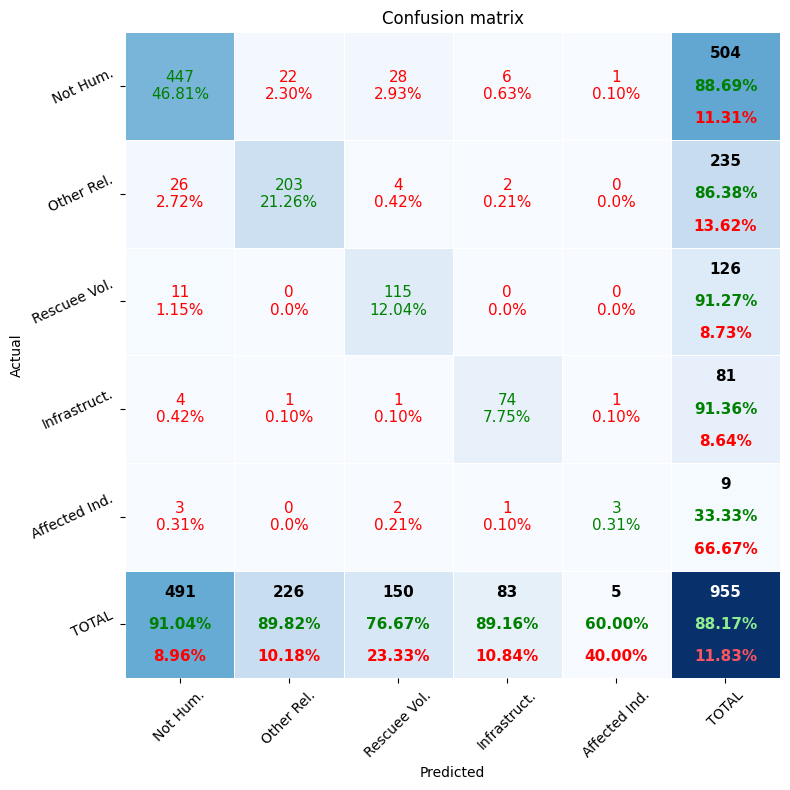

In [10]:


import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import sys

# task = sys.argv[1]
# algo = sys.argv[2]
# run = int(sys.argv[3])
task, algo, run = 'humanitarian', 'fixmatch-hard', 1
# task, algo, run = 'humanitarian', 'flexmatch', 1
# task, algo, run = 'humanitarian', 'marginmatch', 1
# task, algo, run = 'humanitarian', 'multihead-apm-agree-5', 1
# task, algo, run = 'humanitarian', 'multihead-apm-agree-5-no-low', 1

assert task == 'humanitarian' or task == 'informative'
assert run == 1 or run == 2

if task == 'humanitarian':
    class_counts = np.array([504, 235, 126, 81, 9])
    columns=["Not Hum.", "Other Rel.", "Rescuee Vol.", "Infrastruct.", "Affected Ind."]

    if algo == 'fixmatch-supervised':
        if run == 1:
            confusion_matrix = [[0.90239044, 0.02788845, 0.0438247,  0.02191235, 0.00398406],
                [0.17021277, 0.81276596, 0.00425532, 0.01276596, 0.        ],
                [0.112,      0.008,      0.864,      0.008,      0.008     ],
                [0.03703704, 0.,         0.04938272, 0.88888889, 0.02469136],
                [0.11111111, 0.,         0.11111111, 0.11111111, 0.66666667]]
        elif run == 2:
            confusion_matrix = [[0.91832669, 0.01593625, 0.0438247,  0.01792829, 0.00398406],
                [0.21276596, 0.76595745, 0.00851064, 0.01276596, 0.        ],
                [0.176,      0.,         0.816,      0.008,      0.,        ],
                [0.0617284,  0.,         0.01234568, 0.90123457, 0.02469136],
                [0.33333333, 0.,         0.,         0.11111111, 0.55555556]]

    elif algo == 'fixmatch-hard':
        if run == 1:
            confusion_matrix = [[0.88645418, 0.0438247,  0.05577689, 0.01195219, 0.00199203],
                [0.1106383,  0.86382979, 0.01702128, 0.00851064, 0.        ],
                [0.088,      0.,         0.912,      0.,         0.,        ],
                [0.04938272, 0.01234568, 0.01234568, 0.91358025, 0.01234568],
                [0.33333333, 0.,         0.22222222, 0.11111111, 0.33333333]]
        elif run == 2:
            confusion_matrix = [[0.89043825, 0.05378486, 0.04581673, 0.00996016, 0.        ],
                [0.08510638, 0.89361702, 0.00851064, 0.01276596, 0.        ],
                [0.088,      0.016,      0.888,      0.008,      0.        ],
                [0.01234568, 0.01234568, 0.02469136, 0.95061728, 0.        ],
                [0.22222222, 0.,         0.22222222, 0.33333333, 0.22222222]]
            
    elif algo == 'fixmatch-soft':
        if run == 1:
            confusion_matrix = [[0.87848606, 0.03984064, 0.06972112, 0.00796813, 0.00398406],
                [0.09361702, 0.88085106, 0.01276596, 0.01276596, 0.        ],
                [0.048,      0.,         0.944,      0.,         0.008,     ],
                [0.04938272, 0.,         0.02469136, 0.90123457, 0.02469136],
                [0.11111111, 0.,         0.22222222, 0.22222222, 0.44444444]]
        elif run == 2:
            confusion_matrix = [[0.91633466, 0.0438247,  0.03386454, 0.00398406, 0.00199203],
                [0.1106383,  0.85957447, 0.01702128, 0.01276596, 0.        ],
                [0.128,      0.,         0.864,      0.,         0.008     ],
                [0.04938272, 0.01234568, 0.02469136, 0.88888889, 0.02469136],
                [0.11111111, 0.,         0.44444444, 0.11111111, 0.33333333]]
            
    elif algo == 'flexmatch':
        if run == 1:
            confusion_matrix = [[0.87051793, 0.02988048, 0.05577689, 0.02988048, 0.01394422],
                [0.11489362, 0.80425532, 0.04680851, 0.0212766,  0.01276596],
                [0.072,      0.,         0.872,      0.016,      0.04,      ],
                [0.03703704, 0.,         0.01234568, 0.91358025, 0.03703704],
                [0.,         0.,         0.11111111, 0.22222222, 0.66666667]]
        elif run == 2:
            confusion_matrix = [[0.83864542, 0.03187251, 0.05976096, 0.03585657, 0.03386454],
                [0.08085106, 0.83404255, 0.03829787, 0.01702128, 0.02978723],
                [0.056,      0.,         0.872,      0.016,      0.056     ],
                [0.02469136, 0.,         0.01234568, 0.9382716,  0.02469136],
                [0.,         0.,         0.22222222, 0.22222222, 0.55555556]]
            
    elif algo == 'freematch':
        if run == 1:
            confusion_matrix = [[0.85059761, 0.0438247,  0.06175299, 0.03187251, 0.01195219],
                [0.08510638, 0.84255319, 0.03829787, 0.01276596, 0.0212766 ],
                [0.08,       0.,         0.872,      0.024,      0.024,     ],
                [0.03703704, 0.,         0.03703704, 0.88888889, 0.03703704],
                [0.11111111, 0.,         0.11111111, 0.22222222, 0.55555556]]
        elif run == 2:
            confusion_matrix = [[0.84063745, 0.03585657, 0.08167331, 0.02191235, 0.01992032],
                [0.1106383,  0.82553191, 0.03829787, 0.01276596, 0.01276596],
                [0.056,      0.,         0.912,      0.016,      0.016     ],
                [0.04938272, 0.,         0.03703704, 0.88888889, 0.02469136],
                [0.,         0.,         0.44444444, 0.22222222, 0.33333333]]

    elif algo == 'marginmatch':
        confusion_matrix = [[0.8685259,  0.03984064, 0.07569721, 0.01593625, 0.        ],
            [0.10212766, 0.86808511, 0.0212766,  0.00851064, 0.        ],
            [0.04,       0.,         0.96,       0.,         0.        ],
            [0.04938272, 0.02469136, 0.0617284,  0.85185185, 0.01234568],
            [0.11111111, 0.,         0.55555556, 0.,         0.33333333]]

    elif algo == 'multihead':
        if run == 1:
            confusion_matrix = [[0.93824701, 0.01992032, 0.03187251, 0.00996016, 0.        ],
                [0.21702128, 0.74893617, 0.00851064, 0.0212766,  0.00425532],
                [0.088,      0.,         0.912,      0.,         0.,        ],
                [0.04938272, 0.,         0.01234568, 0.91358025, 0.02469136],
                [0.22222222, 0.,         0.11111111, 0.,         0.66666667]]
        elif run == 2:
            confusion_matrix = [[0.92031873, 0.02191235, 0.04183267, 0.01394422, 0.00199203],
                [0.15744681, 0.82553191, 0.00851064, 0.00851064, 0.        ],
                [0.152,      0.,         0.848,      0.,         0.,        ],
                [0.04938272, 0.,         0.02469136, 0.91358025, 0.01234568],
                [0.11111111, 0.,         0.11111111, 0.22222222, 0.55555556]]
            
    elif algo == 'multihead-apm-agree-5':
        if run == 1:
            confusion_matrix = [[0.91035857, 0.02589641, 0.04780876, 0.01593625, 0.        ],
                [0.13617021, 0.82978723, 0.0212766,  0.01276596, 0.        ],
                [0.048,      0.,         0.952,      0.,         0.,        ],
                [0.0617284,  0.,         0.01234568, 0.92592593, 0.        ],
                [0.11111111, 0.,         0.22222222, 0.22222222, 0.44444444]]
        elif run == 2:
            confusion_matrix = [[0.93227092, 0.02390438, 0.03386454, 0.00796813, 0.00199203],
                [0.16170213, 0.82553191, 0.01276596, 0.,         0.        ],
                [0.088,      0.,         0.904,      0.,         0.008,     ],
                [0.07407407, 0.01234568, 0.01234568, 0.87654321, 0.02469136],
                [0.22222222, 0.,         0.22222222, 0.,         0.55555556]]

    elif algo == 'multihead-apm-agree-5-no-low':
        if run == 1:
            confusion_matrix = [[0.94422311, 0.02191235, 0.02191235, 0.01195219, 0.        ],
                [0.14893617, 0.82978723, 0.00851064, 0.00851064, 0.00425532],
                [0.136,      0.,         0.864,      0.,         0.,        ],
                [0.03703704, 0.,         0.,         0.92592593, 0.03703704],
                [0.22222222, 0.,         0.22222222, 0.,         0.55555556]]
        elif run == 2:
            confusion_matrix = [[0.9123506,  0.03187251, 0.03984064, 0.01593625, 0.        ],
                [0.14468085, 0.83829787, 0.00851064, 0.00851064, 0.        ],
                [0.072,      0.,         0.92,       0.,         0.008     ],
                [0.04938272, 0.01234568, 0.01234568, 0.90123457, 0.02469136],
                [0.11111111, 0.,         0.11111111, 0.22222222, 0.55555556]]
    
    elif algo == 'multihead-apm-no-agree-5':
        if run == 1:
            confusion_matrix = [[0.93027888, 0.02390438, 0.03585657, 0.00996016, 0.        ],
                [0.14468085, 0.83404255, 0.01702128, 0.00425532, 0.        ],
                [0.112,      0.,         0.872,      0.,         0.016     ],
                [0.07407407, 0.,         0.01234568, 0.88888889, 0.02469136],
                [0.22222222, 0.,         0.11111111, 0.11111111, 0.55555556]]
        
        elif run == 2:
            confusion_matrix = [[0.89641434, 0.03984064, 0.05577689, 0.0059761,  0.00199203],
                [0.13617021, 0.82978723, 0.02553191, 0.00851064, 0.        ],
                [0.04,       0.,         0.952,      0.,         0.008     ],
                [0.0617284,  0.01234568, 0.03703704, 0.86419753, 0.02469136],
                [0.22222222, 0.,         0.22222222, 0.11111111, 0.44444444]]
            
    elif algo == 'multihead-apm-no-agree-5-no-low':
        if run == 1:
            confusion_matrix = [[0.93227092, 0.02390438, 0.03187251, 0.00996016, 0.00199203],
                [0.15319149, 0.81276596, 0.0212766,  0.01276596, 0.        ],
                [0.12,       0.,         0.864,      0.,         0.016     ],
                [0.03703704, 0.,         0.01234568, 0.9382716,  0.01234568],
                [0.22222222, 0.,         0.11111111, 0.11111111, 0.55555556]]
        
        elif run == 2:
            confusion_matrix = [[0.91035857, 0.03984064, 0.03187251, 0.01792829, 0.        ],
                [0.1106383,  0.87234043, 0.00851064, 0.00851064, 0.        ],
                [0.16,       0.008,      0.832,      0.,         0.,        ],
                [0.0617284,  0.,         0.01234568, 0.92592593, 0.        ],
                [0.22222222, 0.,         0.22222222, 0.11111111, 0.44444444]]

    else:
        assert False

elif task == 'informative':
    class_counts = np.array([1030, 504])
    columns=["Informative", "Not Informative"]

    if algo == 'fixmatch-supervised':
        if run == 1:
            confusion_matrix = [[0.95224172, 0.04775828],
                [0.1812749,  0.8187251 ]]
        elif run == 2:
            confusion_matrix = [[0.96003899, 0.03996101],
                [0.24701195, 0.75298805]]

    elif algo == 'fixmatch-hard':
        if run == 1:
            confusion_matrix = [[0.94152047, 0.05847953],
                [0.187251,   0.812749  ]]
        elif run == 2:
            confusion_matrix = [[0.94054581, 0.05945419],
                [0.18326693, 0.81673307]]
            
    elif algo == 'fixmatch-soft':
        if run == 1:
            confusion_matrix = [[0.94249513, 0.05750487],
                [0.16334661, 0.83665339]]
        elif run == 2:
            confusion_matrix = [[0.93664717, 0.06335283],
                [0.1752988,  0.8247012 ]]
            
    elif algo == 'flexmatch':
        if run == 1:
            confusion_matrix =  [[0.93664717, 0.06335283],
                [0.16533865, 0.83466135]]
        elif run == 2:
            confusion_matrix = [[0.92007797, 0.07992203],
                [0.14741036, 0.85258964]]
            
    elif algo == 'freematch':
        if run == 1:
            confusion_matrix = [[0.92982456, 0.07017544],
                [0.13346614, 0.86653386]]
        elif run == 2:
            confusion_matrix = [[0.90838207, 0.09161793],
                [0.12350598, 0.87649402]]

    elif algo == 'multihead':
        if run == 1:
            confusion_matrix = [[0.93469786, 0.06530214],
                [0.15338645, 0.84661355]]
        elif run == 2:
            confusion_matrix = [[0.94346979, 0.05653021],
                [0.16533865, 0.83466135]]
            
    elif algo == 'multihead-apm-agree-5':
        if run == 1:
            confusion_matrix = [[0.95419103, 0.04580897],
                [0.18326693, 0.81673307]]
        elif run == 2:
            confusion_matrix = [[0.96003899, 0.03996101],
                [0.20119522, 0.79880478]]
    
    elif algo == 'multihead-apm-agree-5-no-low':
        if run == 1:
            confusion_matrix = [[0.9454191,  0.0545809 ],
                [0.14940239, 0.85059761]]
        elif run == 2:
            confusion_matrix = [[0.94249513, 0.05750487],
                [0.15537849, 0.84462151]]
    
    elif algo == 'multihead-apm-no-agree-5':
        if run == 1:
            confusion_matrix = [[0.95516569, 0.04483431],
                [0.187251,   0.812749  ]]
        
        elif run == 2:
            confusion_matrix = [[0.9502924,  0.0497076 ],
                [0.18525896, 0.81474104]]
            
    elif algo == 'multihead-apm-no-agree-5-no-low':
        if run == 1:
            confusion_matrix = [[0.97173489, 0.02826511],
                [0.22709163, 0.77290837]]
        
        elif run == 2:
            confusion_matrix = [[0.94054581, 0.05945419],
                [0.17131474, 0.82868526]]

    elif algo == 'fixmatch-supervised-lb-10':
        confusion_matrix = [[0.43609756, 0.56390244],
            [0.31610338, 0.68389662]]
        
    elif algo == 'multihead-apm-agree-5-no-low-lb-10':
        confusion_matrix =  [[1.,         0.        ],
            [0.99801193, 0.00198807]]

    else:
        assert False



# Calculate F1 score for each class
true_labels = []
pred_labels = []

for i in range(len(confusion_matrix)):
    true_labels.extend([i] * class_counts[i])
    for j in range(len(confusion_matrix[i])):
        pred_labels.extend([j] * round(confusion_matrix[i][j] * class_counts[i]))

assert len(true_labels) == len(pred_labels)

pp_matrix_from_data(y_test=np.array(true_labels), predictions=np.array(pred_labels), pred_val_axis="x", columns=columns, cmap='Blues', show_null_values=2)

#  cmaps: Oranges,Oranges_r,YlGnBu,Blues,RdBu

# # Using scikit-learn to calculate the overall F1 score (macro, micro, or weighted)
# f1_macro = f1_score(true_labels, pred_labels, average='macro')
# f1_micro = f1_score(true_labels, pred_labels, average='micro')
# f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

# precision_macro = precision_score(true_labels, pred_labels, average='macro')
# precision_weighted = precision_score(true_labels, pred_labels, average='weighted')

# recall_macro = recall_score(true_labels, pred_labels, average='macro')
# recall_weighted = recall_score(true_labels, pred_labels, average='weighted')

# print(f'Precision (Macro): {precision_macro}')
# print(f'Precision (Weighted): {round(precision_weighted, 4)}')

# print(f'Recall (Macro): {recall_macro}')
# print(f'Recall (Weighted): {round(recall_weighted, 4)}')

# print(f'F1 Score (Macro): {f1_macro}')
# print(f'F1 Score (Micro): {f1_micro}')
# print(f'F1 Score (Weighted): {round(f1_weighted, 4)}')


In [4]:
diag_color='black'
diag_color2 = 'white'
diag_color_g = 'lightgreen'
diag_color_r = '#fb5561'
# diag_color_r = '#f6688e'

In [34]:
import cmasher as cmr

cmap = cmr.get_sub_cmap('Blues', 0.1, 0.9)

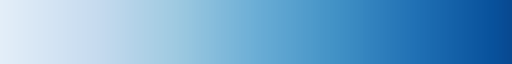

In [35]:
cmap

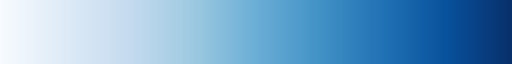

In [33]:
cmap